In [2]:
# script to set up the monte carlo sampling for the top 100 params
# script to save the rankings for the mechanism
import os
import re
import sys
import glob
import copy
import yaml
import pickle
import subprocess
import numpy as np
import pandas as pd

import rmgpy.data.kinetics
import rmgpy.chemkin
import cantera as ct


sys.path.append('/work/westgroup/harris.se/autoscience/reaction_calculator/database/')
import importlib
import database_fun
importlib.reload(database_fun)

import matplotlib.pyplot as plt
%matplotlib inline




In [12]:
run0 = np.load('delays_0000.npy')

In [5]:
base = np.load('base_delays.npy')

In [8]:
Tlist = [700, 731, 756, 794, 840, 872, 906, 926, 959, 1000]

In [15]:
run_files = glob.glob('delays_*.npy')
M = 1000
run_data = np.zeros((len(run_files) * M, len(Tlist)))
for f in range(len(run_files)):
    run_data[f * M: (f + 1) * M, :] = np.load(run_files[f])

In [22]:
run_data = np.load('delays_0000.npy')

In [31]:
run_data[run_data < 0] = np.nan

Text(0.5, 1.0, 'Global Uncertainty for RMG-7')

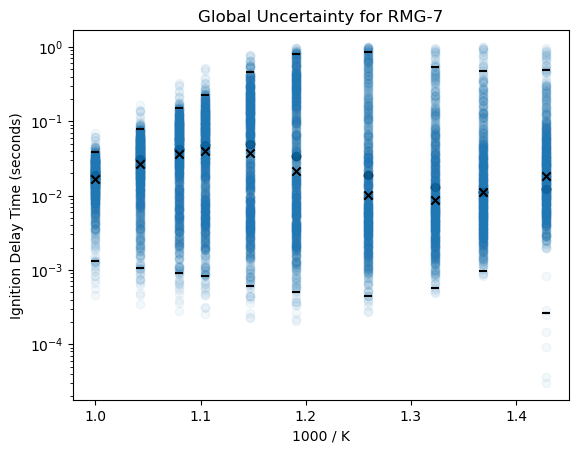

In [35]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']


plt.scatter(1000.0 / np.array(Tlist), base, marker='o', color='black')
for i in range(len(Tlist)):
    plt.scatter(1000.0 / np.array([Tlist[i]] * run_data.shape[0]), run_data[:, i], alpha = 0.05, color=colors[0])
    plt.scatter(1000.0 / Tlist[i], np.nanmedian(run_data[:, i]), marker='x', color='black')
    
    plt.scatter(1000.0 / Tlist[i], np.nanpercentile(run_data[:, i], 50 + 95.45 / 2.0), marker='_', color='black')  # 2 standard deviations
    
#     print(Tlist[i], np.percentile(run0[:, i], 50 - 95.45 / 2.0))
    plt.scatter(1000.0 / Tlist[i], np.nanpercentile(run_data[:, i], 50 - 95.45 / 2.0), marker='_', color='black')
    
ax = plt.gca()
ax.set_yscale('log')
plt.xlabel('1000 / K')
plt.ylabel('Ignition Delay Time (seconds)')
plt.title('Global Uncertainty for RMG-7')

In [4]:
run0.shape

(1000, 10)

700 -1.0302160327815375
731 -1.017197506244458
756 -1.0105814269465532
794 -1.0067520146928133
840 -0.782598736278882
872 0.0004757067269161861
906 0.0008295754473695194
926 0.0009227016221564163
959 0.0010553483053921697
1000 0.00132102846340397


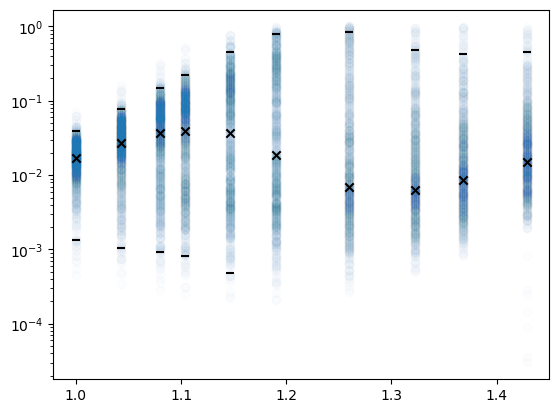

In [14]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for i in range(len(Tlist)):
    plt.scatter(1000.0 / np.array([Tlist[i]] * run0.shape[0]), run0[:, i], alpha = 0.01, color=colors[0])
    plt.scatter(1000.0 / Tlist[i], np.median(run0[:, i]), marker='x', color='black')
    plt.scatter(1000.0 / Tlist[i], np.percentile(run0[:, i], 50 + 95.45 / 2.0), marker='_', color='black')  # 2 standard deviations
    
    print(Tlist[i], np.percentile(run0[:, i], 50 - 95.45 / 2.0))
    plt.scatter(1000.0 / Tlist[i], np.percentile(run0[:, i], 50 - 95.45 / 2.0), marker='_', color='black')
    
ax = plt.gca()
ax.set_yscale('log')

In [ ]:
# throw out negatives??

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
for i in range(len(Tlist)):
    plt.scatter(1000.0 / np.array([Tlist[i]] * run0.shape[0]), run0[:, i], alpha = 0.01, color=colors[0])
    plt.scatter(1000.0 / Tlist[i], np.median(run0[:, i]), marker='x', color='black')
    plt.scatter(1000.0 / Tlist[i], np.percentile(run0[:, i], 50 + 95.45 / 2.0), marker='_', color='black')  # 2 standard deviations
    
    print(Tlist[i], np.percentile(run0[:, i], 50 - 95.45 / 2.0))
    plt.scatter(1000.0 / Tlist[i], np.percentile(run0[:, i], 50 - 95.45 / 2.0), marker='_', color='black')
    
ax = plt.gca()
ax.set_yscale('log')